# Logistic Regression #

Se usa conmunmente para estimar la probabilidad de que una instancia pertenezca a una clase o categoria en particular.

$ \hat{p} = h_{\theta} (x) = \sigma (x^{T}\theta) $

Donde $\sigma$ representa la función sigmoidea

$\sigma (t) = \frac{1}{1+e^{-t}}$

La función de costo o gunción de pérdida se conoce con el nombre de entropía cruzada, corresponde al costo promedio sobre todas las instancias de entrenamiento.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import sklearn 
import seaborn as sns

In [2]:
data = pd.read_csv("Datasets/breast_cancer_dataset.csv")
data.head(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Volviendo los datos unos vectores para aplicar el modelo.

In [3]:
lista = [x for x in data.columns if x != "target"]
x = np.array(data[lista])
y = np.array(data[["target"]])

#print(x, "\n")
#print(y, "\n")

Llevando los datos a una misma escala, esto debido a que hay sesgo en los datos. 

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x = scaler.fit_transform(x)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

log = LogisticRegression() #Creando el modelo

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2) #Separando los datos

In [6]:
log.fit(x_train, y_train) #Entrenando los datos

/home/fisica8/anaconda3/envs/David_Luque/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [7]:
y_pred = log.predict(x_test)
y_pred

array([1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0])

Se va a crear una matriz de confusión. 

In [8]:
from sklearn.metrics import confusion_matrix

M = confusion_matrix(y_test, y_pred) #Se genera la matriz de confusión

Text(37.722222222222264, 0.5, 'Valores Reales')

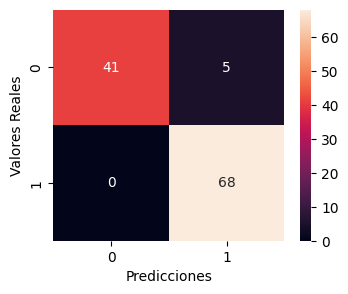

In [9]:
plt.figure(figsize = (4,3))
sns.heatmap(M, square = True, annot = True)
plt.xlabel("Predicciones")
plt.ylabel("Valores Reales")

In [10]:
from sklearn.metrics import accuracy_score

print("Accuracy_score: ", accuracy_score(y_test, y_pred))

Accuracy_score:  0.956140350877193


In [11]:
from sklearn.metrics import precision_score

print("precision_score: ", precision_score(y_test, y_pred))

precision_score:  0.9315068493150684


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        46
           1       0.93      1.00      0.96        68

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Otra forma de visualizar los datos es a través de la curva Roc

In [13]:
from sklearn.metrics import roc_auc_score, roc_curve

fpr, tpr, thereshold = roc_curve(y_test, y_pred) # Falsos positivos rate, true positive rate, umbral

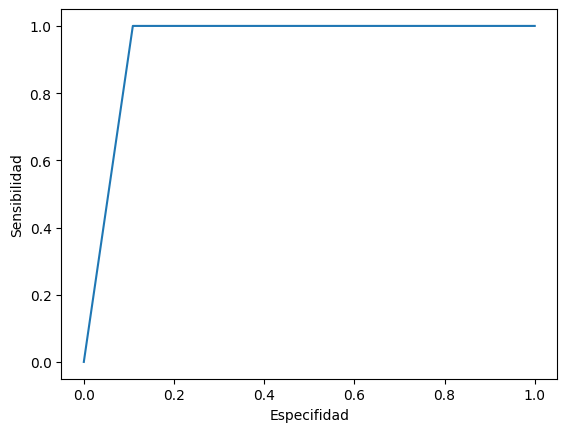

In [14]:
plt.plot(fpr, tpr)
plt.xlabel("Especifidad")
plt.ylabel("Sensibilidad")
plt.show()

El coeficiente mide el área bajo la curva, dice que tanto se ajustan los datos al modelo. 

In [15]:
print(roc_auc_score(y_test, y_pred))

0.9456521739130435


In [16]:
log.intercept_, log.coef_ #Coeficiente y pesos asociados a cada característica. 

(array([0.99797849]),
 array([[-0.57533305, -0.54076822, -0.55971596, -0.59461238,  0.14397787,
          0.32251875, -0.80444075, -0.91504241, -0.20282044,  0.3760988 ,
         -0.57159125,  0.42200038, -0.29371042, -0.7265384 , -0.53710365,
          0.53149617, -0.05699717, -0.01233497,  0.08843989,  0.6099967 ,
         -1.03549073, -1.40827596, -0.86880778, -1.02006813, -0.8640394 ,
          0.13435485, -0.78663508, -1.13744925, -0.91929376, -0.1339592 ]]))

# Validación cruzada #

La idea es dividir los datos en múltiples particiones y entrenar el modelo en diferentes combinaciones de estas particiones.

In [17]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(log, x_train, y_train, scoring = "accuracy", cv = 10) 
#El primer parámetro es el objeto al que se le hará la validación cruzada
#El segundo y tercer parámetro son los datos con los que se hará la validación cruzada
#EL 4to aún no entiendo bien pa qué es
#El 5to es el número de particiones

/home/fisica8/anaconda3/envs/David_Luque/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/fisica8/anaconda3/envs/David_Luque/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/fisica8/anaconda3/envs/David_Luque/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/fisica8/anaconda3/envs/David_Luque/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWar

In [18]:
score

array([0.97826087, 1.        , 1.        , 0.97826087, 0.97826087,
       0.97777778, 1.        , 0.97777778, 0.93333333, 0.97777778])

In [19]:
score.mean()

np.float64(0.980144927536232)

In [20]:
from Fisica.regresion_logistica import RegresionLogistica

In [21]:
rl = RegresionLogistica()

In [22]:
rl.fit(x_train, y_train)

In [23]:
y_pred = rl.predict(x_test)

In [24]:
confusion_matrix(y_test,y_pred)

array([[41,  5],
       [ 0, 68]])

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        46
           1       0.93      1.00      0.96        68

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [26]:
y_pred


array([[1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
    